In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import PIL.ImageOps
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. DATASET SETUP ---
class TwoDigitMNIST(Dataset):
    def __init__(self, train=True):
        self.mnist = torchvision.datasets.MNIST(
            root='./data', train=train, download=True,
            transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ]))
    def __len__(self):
        return len(self.mnist) // 2
    def __getitem__(self, idx):
        img1, label1 = self.mnist[idx * 2]
        img2, label2 = self.mnist[idx * 2 + 1]
        combined_img = torch.cat((img1, img2), dim=2) # Combine side-by-side
        return combined_img, torch.tensor([label1, label2])

# Prepare Loaders
train_loader = DataLoader(TwoDigitMNIST(train=True), batch_size=64, shuffle=True)

# --- 2. MODEL DEFINITION ---
class TwoDigitCNN(nn.Module):
    def __init__(self):
        super(TwoDigitCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_common = nn.Linear(64 * 7 * 14, 256)
        self.fc_digit1 = nn.Linear(256, 10) # Head for 1st digit
        self.fc_digit2 = nn.Linear(256, 10) # Head for 2nd digit

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1) # Flatten
        x = torch.relu(self.fc_common(x))
        return self.fc_digit1(x), self.fc_digit2(x)

model = TwoDigitCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 3. TRAINING (Quick Run: 1 Epoch) ---
print("Starting training...")
model.train()
for i, (images, labels) in enumerate(train_loader):
    optimizer.zero_grad()
    out1, out2 = model(images)
    loss = criterion(out1, labels[:, 0]) + criterion(out2, labels[:, 1])
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
        print(f"Batch {i}, Loss: {loss.item():.4f}")

print("Training Complete!")

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.43MB/s]


Starting training...
Batch 0, Loss: 4.6041
Batch 100, Loss: 0.4722
Batch 200, Loss: 0.1860
Batch 300, Loss: 0.1466
Batch 400, Loss: 0.1327
Training Complete!


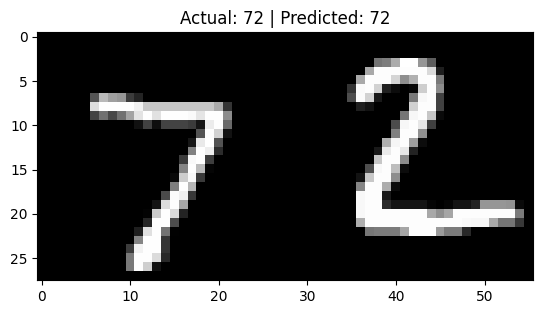

In [5]:
# Test on one sample from the dataset
model.eval()
test_data = TwoDigitMNIST(train=False)
img, label = test_data[0] # Get the first test pair

with torch.no_grad():
    o1, o2 = model(img.unsqueeze(0))
    pred1 = torch.argmax(o1).item()
    pred2 = torch.argmax(o2).item()

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Actual: {label[0].item()}{label[1].item()} | Predicted: {pred1}{pred2}")
plt.show()